# Assignment 3: Bug Fixing — Tokenizer & Pre-training
**CSCI 455/555 — Spring 2026 | Prof. Antonio Mastropaolo**

Notebook **1 of 3**. We:
1. Train a SentencePiece Unigram tokenizer on 50K Java methods from CodeSearchNet.
2. Pre-train T5-small from scratch with the span-corruption objective for 3 epochs.

Outputs feed directly into Notebook 2 (fine-tuning).

## 0.1) Install Dependencies

In [7]:
!pip install -q transformers==4.46.0 tokenizers==0.20.3 sentencepiece==0.2.0
!pip install -q "datasets>=2.21.0" torch tqdm matplotlib
from IPython.display import clear_output; clear_output(); print("Installations Complete")

Installations Complete


## 0.2) Imports

In [8]:
import os
import random
import json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

import sentencepiece as spm
from transformers import T5Config, T5Tokenizer, T5ForConditionalGeneration
from datasets import load_dataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## 0.3) Configuration Settings

In [9]:
# =======================================================================
# Paths (Google Colab)
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR       = r"/content/drive/MyDrive/W&M/GenAI/Assignment_3"
DATA_DIR       = f"{BASE_DIR}/data"
TOKENIZER_DIR  = f"{BASE_DIR}/tokenizer"
PRETRAINED_DIR = f"{BASE_DIR}/pretrained"

for d in (DATA_DIR, TOKENIZER_DIR, PRETRAINED_DIR):
    os.makedirs(d, exist_ok=True)

# =======================================================================
# Tokenizer
# Train SentencePiece with 16,284 pieces; T5Tokenizer adds 100 sentinels on top
# => final vocab = 16,384 (matches assignment spec).
SP_VOCAB_SIZE  = 16_284
SENTINEL_COUNT = 100
TARGET_VOCAB   = 16_384

# =======================================================================
# Pre-training corpus
CORPUS_SIZE = 50_000
MIN_TOKENS  = 10
MAX_TOKENS  = 512
RANDOM_SEED = 42

# =======================================================================
# T5-small architecture (manual — per assignment spec)
D_MODEL        = 512
D_FF           = 2048
D_KV           = 64
NUM_HEADS      = 8
NUM_LAYERS     = 6
NUM_DEC_LAYERS = 6

# =======================================================================
# Pre-training hyperparameters
PRETRAIN_EPOCHS     = 3
PRETRAIN_BATCH_SIZE = 16
PRETRAIN_LR         = 1e-4
CORRUPTION_RATE     = 0.15
PRETRAIN_MAX_LEN    = 512

# =======================================================================
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("✓ Configuration loaded")
print(f"  Base dir     : {BASE_DIR}")
print(f"  Corpus size  : {CORPUS_SIZE:,} methods")
print(f"  Target vocab : {TARGET_VOCAB:,}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Configuration loaded
  Base dir     : /content/drive/MyDrive/W&M/GenAI/Assignment_3
  Corpus size  : 50,000 methods
  Target vocab : 16,384


---
---

# Task 1: Data Preparation

---
---

## 1.1) Load Java Methods from CodeSearchNet

CodeSearchNet is a well-established benchmark (~2M methods across 6 languages). We sample 50K Java methods from the `train` split — `whole_func_string` contains the full method source.

In [10]:
csn = load_dataset("code_search_net", "java", split="train", trust_remote_code=True)
print(f"Full Java train split : {len(csn):,} methods")

# Shuffle and take 60K (we will trim to 50K after filtering)
raw = csn.shuffle(seed=RANDOM_SEED).select(range(60_000))
raw_methods = [s["whole_func_string"] for s in raw if s["whole_func_string"]]
print(f"Pulled {len(raw_methods):,} raw methods")
print(f"\nSample (first 200 chars):\n{raw_methods[0][:200]}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'code_search_net' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'code_search_net' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse th

README.md: 0.00B [00:00, ?B/s]

java/train-00000-of-00001.parquet:   0%|          | 0.00/390M [00:00<?, ?B/s]

java/test-00000-of-00001.parquet:   0%|          | 0.00/23.8M [00:00<?, ?B/s]

java/validation-00000-of-00001.parquet:   0%|          | 0.00/12.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/454451 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/26909 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/15328 [00:00<?, ? examples/s]

Full Java train split : 454,451 methods
Pulled 60,000 raw methods

Sample (first 200 chars):
public void put(String entityTypeId, Entity entity) {
    CombinedEntityCache entityCache = caches.get();
    if (entityCache != null) {
      entityCache.put(entity);
      LOG.trace(
          "Adde


## 1.2) Write Raw Corpus for Tokenizer Training

The tokenizer is trained on *unfiltered* methods so its vocabulary reflects the full distribution of code. We filter by token length **after** training (once we have a tokenizer).

In [11]:
CORPUS_TXT = f"{DATA_DIR}/pretrain_corpus_raw.txt"

with open(CORPUS_TXT, "w", encoding="utf-8") as f:
    for m in raw_methods:
        # Collapse internal newlines so each method sits on one line for SP
        f.write(m.replace("\n", " ").replace("\r", " ").strip() + "\n")

print(f"Wrote {len(raw_methods):,} lines → {CORPUS_TXT}")
print(f"File size: {os.path.getsize(CORPUS_TXT) / 1e6:.1f} MB")

Wrote 60,000 lines → /content/drive/MyDrive/W&M/GenAI/Assignment_3/data/pretrain_corpus_raw.txt
File size: 43.1 MB


---
---

# Task 2: SentencePiece Tokenizer

---
---

## 2.1) Train SentencePiece (Unigram)

- **Algorithm**: Unigram (top-down pruning — better for rare identifiers than BPE).
- **Vocab size**: 16,284 SP pieces → + 100 sentinels = **16,384 final** (matches spec).
- **Special tokens**: `<pad>=0`, `</s>=1`, `<unk>=2`. No BOS (T5 convention).
- `character_coverage=0.9995` — code is ASCII-dominant.


In [12]:
SP_PREFIX = f"{TOKENIZER_DIR}/sp_model"

spm.SentencePieceTrainer.train(
    input=CORPUS_TXT,
    model_prefix=SP_PREFIX,
    vocab_size=SP_VOCAB_SIZE,
    model_type="unigram",
    character_coverage=0.9995,
    pad_id=0, eos_id=1, unk_id=2, bos_id=-1,
    pad_piece="<pad>", eos_piece="</s>", unk_piece="<unk>",
    input_sentence_size=500_000,
    shuffle_input_sentence=True,
    train_extremely_large_corpus=False,
)
print(f"✓ SentencePiece trained → {SP_PREFIX}.model")

✓ SentencePiece trained → /content/drive/MyDrive/W&M/GenAI/Assignment_3/tokenizer/sp_model.model


## 2.2) Wrap as HuggingFace `T5Tokenizer`

`T5Tokenizer` manages the 100 sentinel tokens (`<extra_id_0>` … `<extra_id_99>`) itself. With `extra_ids=100`, the final tokenizer has `len(tokenizer) = 16,284 + 100 = 16,384` — the sentinels map to IDs `16,383 … 16,284` (highest-to-lowest).

In [13]:
tokenizer = T5Tokenizer(
    vocab_file=f"{SP_PREFIX}.model",
    extra_ids=SENTINEL_COUNT,
    legacy=False,
)
tokenizer.save_pretrained(TOKENIZER_DIR)
print(f"✓ Tokenizer saved → {TOKENIZER_DIR}")
print(f"  len(tokenizer)  : {len(tokenizer)}")
print(f"  pad/eos/unk IDs : {tokenizer.pad_token_id}, {tokenizer.eos_token_id}, {tokenizer.unk_token_id}")

✓ Tokenizer saved → /content/drive/MyDrive/W&M/GenAI/Assignment_3/tokenizer
  len(tokenizer)  : 16384
  pad/eos/unk IDs : 0, 1, 2


## 2.3) Sanity Checks

In [14]:
print("=" * 60)
print("Special tokens")
print("=" * 60)
for t in ["<pad>", "</s>", "<unk>", "<extra_id_0>", "<extra_id_42>", "<extra_id_99>"]:
    print(f"  {t:<16} → {tokenizer.convert_tokens_to_ids(t)}")

print("\n" + "=" * 60)
print("Tokenization example")
print("=" * 60)
sample = "public static int add(int a, int b) { return a + b; }"
ids = tokenizer.encode(sample)
toks = tokenizer.convert_ids_to_tokens(ids)
print(f"Text  : {sample}")
print(f"Tokens: {toks}")
print(f"IDs   : {ids}")
print(f"Round-trip: {tokenizer.decode(ids)}")

# Confirm all 100 sentinels resolve to distinct valid IDs
sent_ids = [tokenizer.convert_tokens_to_ids(f"<extra_id_{i}>") for i in range(SENTINEL_COUNT)]
assert len(set(sent_ids)) == SENTINEL_COUNT, "sentinel IDs not unique!"
print(f"\n✓ All {SENTINEL_COUNT} sentinels unique. Range: [{min(sent_ids)}, {max(sent_ids)}]")

Special tokens
  <pad>            → 0
  </s>             → 1
  <unk>            → 2
  <extra_id_0>     → 16383
  <extra_id_42>    → 16341
  <extra_id_99>    → 16284

Tokenization example
Text  : public static int add(int a, int b) { return a + b; }
Tokens: ['▁public', '▁static', '▁int', '▁add', '(', 'int', '▁a', ',', '▁int', '▁b', ')', '▁{', '▁return', '▁a', '▁+', '▁b', ';', '▁}', '</s>']
IDs   : [21, 53, 35, 180, 4, 78, 76, 9, 35, 221, 7, 8, 17, 76, 28, 221, 14, 6, 1]
Round-trip: public static int add(int a, int b) { return a + b; }</s>

✓ All 100 sentinels unique. Range: [16284, 16383]


---
---

# Task 3: Model Initialization

---
---

## 3.1) Manual `T5Config` (T5-small ≈ 60M params)

Following Mastropaolo et al. (ASE 2023) — every architectural choice defined explicitly, no borrowed config.

In [16]:
t5_config = T5Config(
    decoder_start_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id,
    bos_token_id=tokenizer.pad_token_id,  # T5 uses pad as decoder start
    pad_token_id=tokenizer.pad_token_id,
    d_model=D_MODEL,
    d_ff=D_FF,
    d_kv=D_KV,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    num_decoder_layers=NUM_DEC_LAYERS,
    vocab_size=len(tokenizer),
    feed_forward_proj="relu",
)

model = T5ForConditionalGeneration(config=t5_config)
model.resize_token_embeddings(len(tokenizer))
model = model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"✓ Model initialized from scratch")
print(f"  Parameters : {n_params / 1e6:.1f}M")
print(f"  Vocab      : {model.config.vocab_size}")
print(f"  d_model    : {model.config.d_model}")
print(f"  Layers     : {model.config.num_layers}/{model.config.num_decoder_layers}")

✓ Model initialized from scratch
  Parameters : 52.4M
  Vocab      : 16384
  d_model    : 512
  Layers     : 6/6


---
---

# Task 4: Span Corruption Data Pipeline

---
---

## 4.1) Filter Corpus by Token Length

Assignment requires methods with **10–512 tokens after tokenization**.

In [17]:
filtered = []
for m in tqdm(raw_methods, desc="Tokenizing & filtering"):
    ids = tokenizer.encode(m, add_special_tokens=False)
    n = len(ids)
    if MIN_TOKENS <= n <= MAX_TOKENS:
        filtered.append(ids)
    if len(filtered) >= CORPUS_SIZE:
        break

print(f"Kept {len(filtered):,}/{len(raw_methods):,} methods (10-512 tokens)")
lengths = np.array([len(x) for x in filtered])
print(f"Length stats: mean={lengths.mean():.0f}  median={np.median(lengths):.0f}  max={lengths.max()}")

Tokenizing & filtering:  87%|████████▋ | 51992/60000 [00:35<00:05, 1465.32it/s]

Kept 50,000/60,000 methods (10-512 tokens)
Length stats: mean=112  median=79  max=512


## 4.2) Span Corruption (T5 objective)

Replace contiguous spans covering ~15% of tokens with sentinel tokens. The decoder target contains only the dropped spans, delimited by sentinels, ending with a final sentinel marker.

In [18]:
# Cache sentinel IDs once — faster than repeated lookups
SENTINEL_IDS = [tokenizer.convert_tokens_to_ids(f"<extra_id_{i}>")
                for i in range(SENTINEL_COUNT)]
PAD_ID = tokenizer.pad_token_id
EOS_ID = tokenizer.eos_token_id


def span_corruption(input_ids, corruption_rate=CORRUPTION_RATE):
    """T5-style span corruption. input_ids: 1-D LongTensor. Returns (enc_input, dec_target)."""
    length = input_ids.size(0)
    eligible = [i for i in range(length) if input_ids[i].item() not in (PAD_ID, EOS_ID)]
    if not eligible:
        return input_ids, torch.tensor([SENTINEL_IDS[0]], dtype=torch.long)

    num_to_corrupt = max(1, int(len(eligible) * corruption_rate))
    corrupted = set(random.sample(eligible, min(num_to_corrupt, len(eligible))))

    # Group consecutive corrupted positions into spans
    spans, cur = [], []
    for pos in sorted(corrupted):
        if cur and pos != cur[-1] + 1:
            spans.append(cur); cur = []
        cur.append(pos)
    if cur:
        spans.append(cur)

    # Cap at (sentinel_count - 1) — need one sentinel for the end marker
    spans = spans[:SENTINEL_COUNT - 1]

    # Encoder input — replace each span with one sentinel
    enc, i, k = [], 0, 0
    while i < length:
        if k < len(spans) and i == spans[k][0]:
            enc.append(SENTINEL_IDS[k])
            i = spans[k][-1] + 1
            k += 1
        else:
            enc.append(input_ids[i].item())
            i += 1

    # Decoder target — sentinel + span tokens, then a final sentinel
    dec = []
    for idx, span in enumerate(spans):
        dec.append(SENTINEL_IDS[idx])
        for pos in span:
            dec.append(input_ids[pos].item())
    dec.append(SENTINEL_IDS[len(spans)])

    return (torch.tensor(enc, dtype=torch.long),
            torch.tensor(dec, dtype=torch.long))


# Test the function on a short sample
sample_ids = torch.tensor(filtered[0][:40], dtype=torch.long)
enc, dec = span_corruption(sample_ids)
print("ENC:", tokenizer.decode(enc))
print("\nDEC:", tokenizer.decode(dec))

ENC: public <extra_id_0> put(String entityTypeId <extra_id_1> entity) { Combined <extra_id_2> entityCache <extra_id_3> caches.get(); if (entityCache != null) { entityCache.put(entity); LOG.trace

DEC: <extra_id_0> void <extra_id_1> , Entity <extra_id_2> EntityCache <extra_id_3> = <extra_id_4>


## 4.3) Dataset & Collate Function

Tokenization is done upfront (in the filter step), so `__getitem__` only applies fresh corruption — giving the model a different mask every epoch.

In [19]:
class SpanCorruptionDataset(Dataset):
    def __init__(self, token_id_lists):
        self.data = token_id_lists

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ids = torch.tensor(self.data[idx], dtype=torch.long)
        enc, dec = span_corruption(ids)
        return {"input_ids": enc, "labels": dec}


def collate(batch):
    inp = [b["input_ids"] for b in batch]
    lbl = [b["labels"]    for b in batch]

    max_i = max(x.size(0) for x in inp)
    max_l = max(x.size(0) for x in lbl)

    padded_inp  = torch.full((len(batch), max_i), PAD_ID, dtype=torch.long)
    attn        = torch.zeros((len(batch), max_i),       dtype=torch.long)
    padded_lbl  = torch.full((len(batch), max_l), -100,  dtype=torch.long)

    for i, (x, y) in enumerate(zip(inp, lbl)):
        padded_inp[i, :x.size(0)] = x
        attn[i, :x.size(0)] = 1
        padded_lbl[i, :y.size(0)] = y

    return {"input_ids": padded_inp, "attention_mask": attn, "labels": padded_lbl}


dataset = SpanCorruptionDataset(filtered)
loader  = DataLoader(dataset, batch_size=PRETRAIN_BATCH_SIZE,
                     shuffle=True, collate_fn=collate,
                     num_workers=2, pin_memory=True)

print(f"Dataset     : {len(dataset):,} samples")
print(f"Batches/epoch: {len(loader):,}")

Dataset     : 50,000 samples
Batches/epoch: 3,125


## 4.4) Inspect a Batch

In [20]:
batch = next(iter(loader))
print("Shapes:")
for k, v in batch.items():
    print(f"  {k:<18} {tuple(v.shape)}")

print("\nSample 0 — encoder input (first 120 chars):")
print(tokenizer.decode(batch['input_ids'][0], skip_special_tokens=False)[:120])

lbl = batch['labels'][0].clone()
lbl[lbl == -100] = PAD_ID
print("\nSample 0 — decoder target (first 120 chars):")
print(tokenizer.decode(lbl, skip_special_tokens=False)[:120])

Shapes:
  input_ids          (16, 264)
  attention_mask     (16, 264)
  labels             (16, 75)

Sample 0 — encoder input (first 120 chars):
private void value(final <extra_id_0> val, final String quote <extra_id_1> ) throws <extra_id_2> { if (val == <extra_id_

Sample 0 — decoder target (first 120 chars):
<extra_id_0> String <extra_id_1> Char <extra_id_2> IOException <extra_id_3> null) <extra_id_4> quote <extra_id_5> q <ext


---
---

# Task 5: Pre-training Loop

---
---

## 5.1) Training — 3 Epochs, Flat

Per assignment spec:
- 3 epochs on the full corpus
- No validation split, no early stopping, no checkpoint selection
- Log per-epoch loss to confirm it decreases
- Use final-epoch weights

In [21]:
optimizer = torch.optim.AdamW(model.parameters(), lr=PRETRAIN_LR)
scaler    = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

epoch_losses = []
step_losses  = []

for epoch in range(PRETRAIN_EPOCHS):
    model.train()
    running = 0.0
    n_batches = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch + 1}/{PRETRAIN_EPOCHS}")
    for batch in pbar:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        if scaler is not None:
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = out.loss
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = out.loss
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        running += loss.item()
        n_batches += 1
        step_losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.3f}")

    avg = running / n_batches
    epoch_losses.append(avg)
    print(f"Epoch {epoch + 1}/{PRETRAIN_EPOCHS} — avg train loss: {avg:.4f}")

print("\n✓ Pre-training complete")
print("Per-epoch avg losses:", [f"{l:.3f}" for l in epoch_losses])

Epoch 1/3: 100%|██████████| 3125/3125 [11:52<00:00,  4.38it/s, loss=3.528]


Epoch 1/3 — avg train loss: 4.1703


Epoch 2/3: 100%|██████████| 3125/3125 [11:54<00:00,  4.37it/s, loss=3.645]


Epoch 2/3 — avg train loss: 3.6897


Epoch 3/3: 100%|██████████| 3125/3125 [11:57<00:00,  4.35it/s, loss=3.660]

Epoch 3/3 — avg train loss: 3.6078

✓ Pre-training complete
Per-epoch avg losses: ['4.170', '3.690', '3.608']


## 5.2) Loss Curves

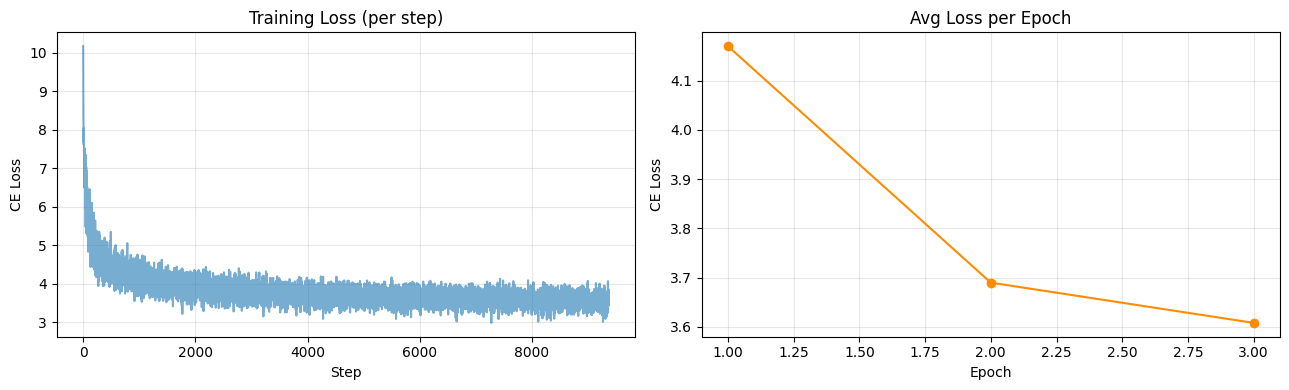

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(step_losses, alpha=0.6)
ax1.set(title="Training Loss (per step)", xlabel="Step", ylabel="CE Loss")
ax1.grid(alpha=0.3)

ax2.plot(range(1, PRETRAIN_EPOCHS + 1), epoch_losses, 'o-', color='darkorange')
ax2.set(title="Avg Loss per Epoch", xlabel="Epoch", ylabel="CE Loss")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PRETRAINED_DIR}/pretrain_loss.png", dpi=150)
plt.show()

## 5.3) Save Final Checkpoint

In [23]:
model.save_pretrained(PRETRAINED_DIR)
tokenizer.save_pretrained(PRETRAINED_DIR)

with open(f"{PRETRAINED_DIR}/pretrain_losses.json", "w") as f:
    json.dump({"epoch_losses": epoch_losses, "step_losses": step_losses}, f)

print(f"✓ Saved pre-trained model + tokenizer → {PRETRAINED_DIR}")
print(f"  Files: {sorted(os.listdir(PRETRAINED_DIR))}")

✓ Saved pre-trained model + tokenizer → /content/drive/MyDrive/W&M/GenAI/Assignment_3/pretrained
  Files: ['added_tokens.json', 'config.json', 'generation_config.json', 'model.safetensors', 'pretrain_loss.png', 'pretrain_losses.json', 'special_tokens_map.json', 'spiece.model', 'tokenizer_config.json']
